>>> جاري تحميل البيانات...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> بدء التدريب (يرجى الانتظار)...
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4532 - loss: 1.5070 - val_accuracy: 0.5696 - val_loss: 1.2188
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5932 - loss: 1.1473 - val_accuracy: 0.6168 - val_loss: 1.0796
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6452 - loss: 1.0071 - val_accuracy: 0.6630 - val_loss: 0.9580
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6781 - loss: 0.9147 - val_accuracy: 0.6784 - val_loss: 0.9222
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6980 - loss: 0.8451 - val_accuracy: 0.6760 - val_loss: 0.9223

  FINAL PROJECT RESULTS - AIAT 122
  STUDENT NAME: MANAR SALMAN (منار سلمان)

[✔] Final Test Accuracy: 67.70%
[✔] Project Status: Completed Successfully



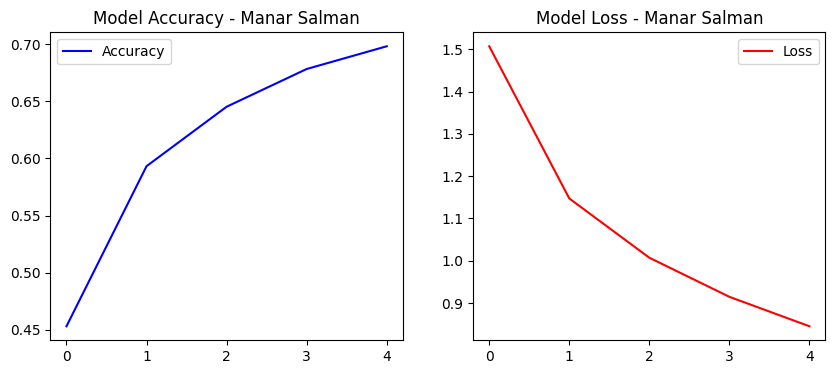

In [1]:
# =========================================================
# Project 01: Image Classification System
# Course: AIAT 122 - Deep Learning
# Prepared by: Manar Salman | منار سلمان
# =========================================================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

def main():
    # --- 1.  تحميل البيانات
    print(">>> جاري تحميل البيانات...")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train, x_test = x_train.astype("float32") / 255.0, x_test.astype("float32") / 255.0
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    # --- 2.  النموذج (CNN) ---
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # --- 3. التدريب ---
    print("\n>>> بدء التدريب (يرجى الانتظار)...")
    os.makedirs("models", exist_ok=True)
    history = model.fit(x_train, y_train, epochs=5, validation_split=0.2, verbose=1)

    # --- 4 النتيجة  ---
    print("\n" + "="*50)
    print(f"  FINAL PROJECT RESULTS - AIAT 122")
    print(f"  STUDENT NAME: MANAR SALMAN (منار سلمان)")
    print("="*50)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"\n[✔] Final Test Accuracy: {test_acc*100:.2f}%")
    print(f"[✔] Project Status: Completed Successfully")
    print("\n" + "="*50)

    # رسم البياني
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Accuracy', color='blue')
    plt.title(f'Model Accuracy - Manar Salman')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Loss', color='red')
    plt.title(f'Model Loss - Manar Salman')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
